In [2]:
%pip install tensorflow --quiet

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [164]:
plt.rcParams['figure.figsize'] = (10,5)


In [165]:
heart_ds = pd.read_csv("/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Projects/heart_disease.csv")
heart_ds.head()


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [166]:
heart_ds['Gender'].value_counts()

Gender
Male      5003
Female    4978
Name: count, dtype: int64

In [167]:
heart_ds.shape

(10000, 21)

In [168]:
heart_ds.isna().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [169]:
heart_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

<h1><center>Visualizations</center><h1>

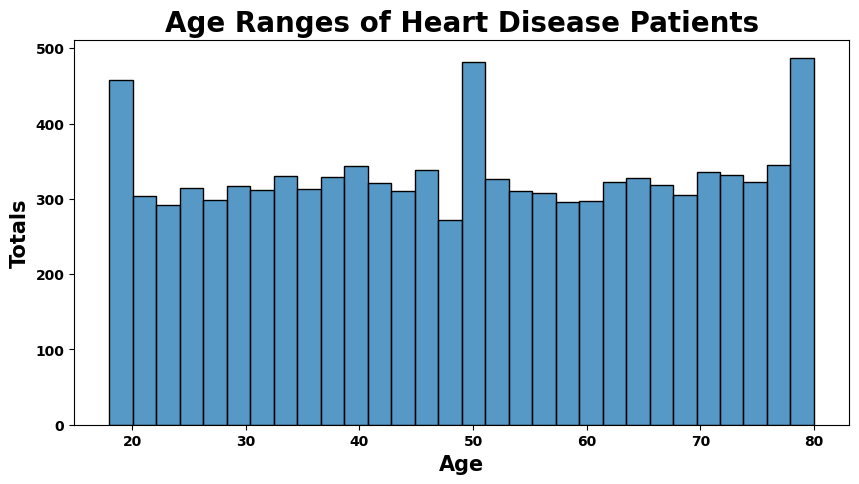

In [170]:
sns.histplot(heart_ds, x = 'Age', bins= 30)
plt.title('Age Ranges of Heart Disease Patients', fontsize = 20, weight = 'bold')
plt.xlabel('Age', fontsize = 15, weight = 'bold')
plt.ylabel('Totals', fontsize = 15, weight = 'bold')
plt.show()

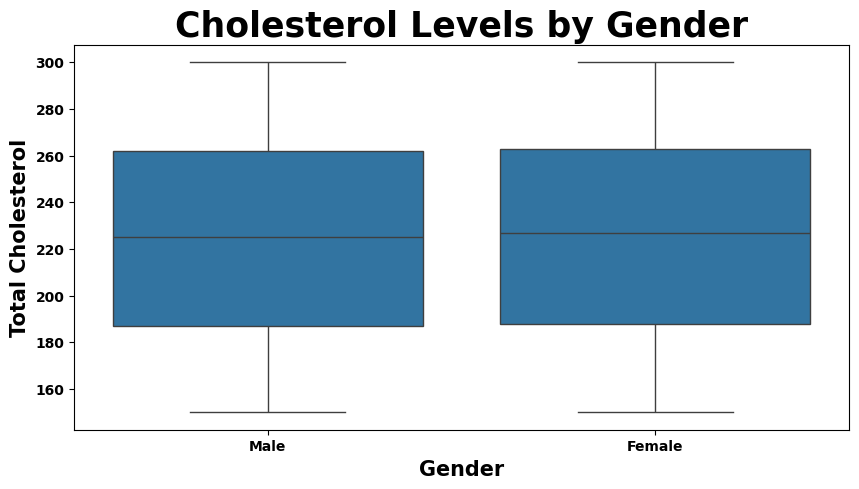

In [171]:
sns.boxplot(heart_ds, x = 'Gender', y = 'Cholesterol Level')
plt.title('Cholesterol Levels by Gender', fontsize = 25, weight = 'bold' )
plt.xlabel('Gender', fontsize = 15, weight = 'bold')
plt.ylabel('Total Cholesterol', fontsize = 15, weight = 'bold')
plt.show()

<h1><center>Preprocessing Data</center></h1>

In [172]:
le = LabelEncoder()

In [173]:
heart_ds['Exercise Habits'] = le.fit_transform(heart_ds['Exercise Habits'])

In [174]:
heart_ds['Alcohol Consumption'] = le.fit_transform(heart_ds['Alcohol Consumption'])

In [175]:
heart_ds['Smoking'] = le.fit_transform(heart_ds['Smoking'])

In [176]:
heart_ds['Family Heart Disease'] = le.fit_transform(heart_ds['Family Heart Disease'])

In [177]:
heart_ds['Diabetes'] = le.fit_transform(heart_ds['Diabetes'])

In [178]:
heart_ds['High Blood Pressure'] = le.fit_transform(heart_ds['High Blood Pressure'])

In [179]:
heart_ds['Low HDL Cholesterol'] = le.fit_transform(heart_ds['Low HDL Cholesterol'])

In [180]:
heart_ds['High LDL Cholesterol'] = le.fit_transform(heart_ds['High LDL Cholesterol'])

In [181]:
heart_ds['Stress Level'] = le.fit_transform(heart_ds['Stress Level'])

In [182]:
heart_ds['Sugar Consumption'] = le.fit_transform(heart_ds['Sugar Consumption'])

In [183]:
heart_ds['Heart Disease Status'] = le.fit_transform(heart_ds['Heart Disease Status'])

In [184]:
heart_ds['BMI'] = heart_ds['BMI'].round(2)

In [185]:
heart_ds['Sleep Hours'] = heart_ds['Sleep Hours'].round(2)

In [186]:
heart_ds['Gender'].replace({'Male': 1, 'Female': 0}, inplace = True)

In [187]:
heart_ds.drop('Alcohol Consumption', axis=1, inplace=True)
              

In [188]:
heart_ds.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,1.0,153.0,155.0,0,1,1,0,24.99,1,1,0,2,7.63,2,342.0,NaN,12.969246,12.387250,0
1,69.0,0.0,146.0,286.0,0,0,1,1,25.22,0,1,0,0,8.74,2,133.0,157.0,9.355389,19.298875,0
2,46.0,1.0,126.0,216.0,1,0,0,0,29.86,0,1,1,1,4.44,1,393.0,92.0,12.709873,11.230926,0
3,32.0,0.0,122.0,293.0,0,1,1,0,24.13,1,0,1,0,5.25,0,293.0,94.0,12.509046,5.961958,0
4,60.0,1.0,166.0,242.0,1,1,1,1,20.49,1,0,0,0,7.03,0,263.0,154.0,10.381259,8.153887,0


<h1><center>Build Model</center></h1>

In [192]:
np.random.seed(0)